# DNA Baseline Models (Traditional Features)

This notebook trains and evaluates classical ML baselines for the DNA task:

- **Task:** promoter vs non-promoter (binary)
- **Input:** engineered baseline features from `05_dna_baseline_features.ipynb`
- **Models covered:**
  - Logistic Regression (scaled)
  - Linear SVM (calibrated, scaled)
  - Random Forest
  - Gradient Boosting
  - XGBoost (**optional**, if installed)

**Outputs:**
- Trained model `.pkl` files saved under `models/dna/baselines/`
- Cross-validation metrics saved to `reports/dna_baseline_cv_results_len{L}.csv`
- Holdout test metrics saved to `reports/dna_baseline_test_results_len{L}.csv`
- Figures saved under `reports/figures/dna_baselines/`
- Summary JSON saved to `reports/dna_baseline_models_summary_len{L}.json`

## 0) (Optional) Install XGBoost

If you're in a conda environment, you can also install with:
- `conda install -c conda-forge xgboost`

After installing, you may need to **restart the kernel** once.

## 1) Imports

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import yaml

import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

import joblib

warnings.filterwarnings("ignore")
np.set_printoptions(suppress=True)

## 2) Paths + config + load features dataset

This notebook expects the engineered features file from notebook `05_dna_baseline_features.ipynb`.

Your filenames look like:
- `data/processed/dna_features_baseline_len200_pos2000_neg2000.csv`
- `data/processed/dna_features_baseline_len200_pos2000_neg2000.parquet`

In [2]:
ROOT = Path.cwd().parents[0]
DATA = ROOT / "data"
PROCESSED = DATA / "processed"
REPORTS = ROOT / "reports"
FIGURES = REPORTS / "figures" / "dna_baselines"
MODELS_DIR = ROOT / "models" / "dna" / "baselines"
CONFIGS = ROOT / "configs"

for p in [REPORTS, FIGURES, MODELS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

cfg_path = CONFIGS / "config.yaml"
assert cfg_path.exists(), f"Missing config: {cfg_path}"
with open(cfg_path, "r") as f:
    cfg = yaml.safe_load(f)

SEED = int(cfg["project"]["random_seed"])
L = int(cfg["dna"]["seq_length_bp"])
N_POS = int(cfg["dna"]["n_pos"])
N_NEG = int(cfg["dna"]["n_neg"])

(SEED, L, N_POS, N_NEG, str(MODELS_DIR))

(42,
 200,
 2000,
 2000,
 '/Users/saturnine/Projects/bio-seq-lm-capstone/models/dna/baselines')

## 3) Find and load feature file (CSV or Parquet)

This is robust to your actual filenames.

In [3]:
# Prefer the most specific expected names, then fall back to glob search
candidates = [
    PROCESSED / f"dna_features_baseline_len{L}_pos{N_POS}_neg{N_NEG}.csv",
    PROCESSED / f"dna_features_baseline_len{L}_pos{N_POS}_neg{N_NEG}.parquet",
    PROCESSED / f"dna_features_baseline_len{L}.csv",
    PROCESSED / f"dna_features_baseline_len{L}.parquet",
]

feat_path = None
for c in candidates:
    if c.exists():
        feat_path = c
        break

# fallback: search for any baseline feature file that matches len{L}
if feat_path is None:
    hits = sorted(PROCESSED.glob(f"dna*_baseline*_len{L}*.csv"))
    if len(hits) == 0:
        hits = sorted(PROCESSED.glob(f"dna*_baseline*_len{L}*.parquet"))
    if len(hits) > 0:
        feat_path = hits[0]

assert feat_path is not None, (
    "Could not find feature CSV/Parquet.\n"
    f"Looked for:\n- " + "\n- ".join([str(x) for x in candidates]) +
    f"\nAnd globbed for dna*_baseline*_len{L}*.(csv|parquet) in {PROCESSED}"
)

print("Using features file:", feat_path)

if feat_path.suffix == ".parquet":
    df = pd.read_parquet(feat_path)
else:
    df = pd.read_csv(feat_path)

df.shape, df.head(2)

Using features file: /Users/saturnine/Projects/bio-seq-lm-capstone/data/processed/dna_features_baseline_len200_pos2000_neg2000.csv


((4000, 100),
   region_id chrom      start        end  label  frac_A  frac_C  frac_G  \
 0    prom_0     4   88592334   88592533      1   0.160   0.385   0.315   
 1    prom_1     5  120078977  120079176      1   0.385   0.140   0.235   
 
    frac_T  frac_N  ...  kmer_3_TCG  kmer_3_TCT  kmer_3_TGA  kmer_3_TGC  \
 0    0.14     0.0  ...         0.0    0.000000    0.005051    0.025253   
 1    0.24     0.0  ...         0.0    0.020202    0.020202    0.005051   
 
    kmer_3_TGG  kmer_3_TGT  kmer_3_TTA  kmer_3_TTC  kmer_3_TTG  kmer_3_TTT  
 0    0.010101    0.005051    0.010101    0.015152    0.025253    0.000000  
 1    0.035354    0.005051    0.020202    0.010101    0.015152    0.010101  
 
 [2 rows x 100 columns])

## 4) Basic checks + build X and y

We keep `region_id/chrom/start/end` as metadata and train on feature columns only.

In [4]:
required_cols = ["label"]
missing = [c for c in required_cols if c not in df.columns]
assert not missing, f"Missing required columns: {missing}"

# Identify metadata columns (keep if present)
meta_cols = [c for c in ["region_id", "chrom", "start", "end", "sequence"] if c in df.columns]

# Define feature columns as everything except metadata + label
feature_cols = [c for c in df.columns if c not in (meta_cols + ["label"])]

X = df[feature_cols].astype(float).values
y = df["label"].astype(int).values

print(df[["label"]].value_counts().sort_index())
print(f"X shape: {X.shape} | y mean: {y.mean():.3f} | n_features: {len(feature_cols)}")

label
0        2000
1        2000
Name: count, dtype: int64
X shape: (4000, 95) | y mean: 0.500 | n_features: 95


## 5) Train / test split (holdout)

Holdout is used for final reporting after CV.

In [5]:
X_train, X_test, y_train, y_test, df_train, df_test = train_test_split(
    X, y, df[meta_cols].copy() if len(meta_cols) > 0 else None,
    test_size=0.2, random_state=SEED, stratify=y
)

(X_train.shape, X_test.shape, y_train.mean(), y_test.mean())

((3200, 95), (800, 95), np.float64(0.5), np.float64(0.5))

## 6) Define baseline models

- Logistic regression: scaled
- Linear SVM: calibrated probabilities (scaled)
- Random forest / Gradient boosting: no scaling
- XGBoost: optional if installed

In [6]:
models = {}

# Logistic Regression (scaled)
models["logreg"] = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=5000,
        solver="lbfgs",
        random_state=SEED,
        n_jobs=None
    ))
])

# Linear SVM + calibration (scaled)
# LinearSVC has no predict_proba, so we calibrate it to get probabilities for ROC/PR metrics.
base_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", LinearSVC(random_state=SEED))
])
models["linear_svm_calibrated"] = CalibratedClassifierCV(
    estimator=base_svm,
    method="sigmoid",
    cv=3
)

# Random Forest
models["random_forest"] = RandomForestClassifier(
    n_estimators=400,
    random_state=SEED,
    n_jobs=-1,
    class_weight=None
)

# Gradient Boosting
models["grad_boost"] = GradientBoostingClassifier(
    random_state=SEED
)

# Optional: XGBoost
try:
    from xgboost import XGBClassifier
    models["xgboost"] = XGBClassifier(
        n_estimators=600,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=SEED,
        n_jobs=-1,
        eval_metric="logloss",
        tree_method="hist"
    )
except Exception as e:
    print("XGBoost not available, skipping. Reason:", repr(e))

list(models.keys())

['logreg', 'linear_svm_calibrated', 'random_forest', 'grad_boost', 'xgboost']

## 7) Cross-validation evaluation

We compute:
- ROC-AUC
- PR-AUC
- Accuracy, Precision, Recall, F1

Results are saved to CSV under `reports/`.

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
}

rows = []
for name, model in models.items():
    res = cross_validate(
        model, X_train, y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )
    row = {"model": name}
    for k, v in res.items():
        if k.startswith("test_"):
            metric = k.replace("test_", "")
            row[f"{metric}_mean"] = float(np.mean(v))
            row[f"{metric}_std"] = float(np.std(v))
    rows.append(row)

cv_df = pd.DataFrame(rows).sort_values(by="roc_auc_mean", ascending=False).reset_index(drop=True)
cv_df

,model,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,random_forest,0.807227,0.014841,0.819449,0.010319,0.715313,0.016607,0.723128,0.021377,0.698750,0.014869,0.710587,0.015230
1,grad_boost,0.802105,0.010219,0.815011,0.007184,0.717187,0.020823,0.724850,0.026473,0.701875,0.022930,0.712836,0.019417
2,logreg,0.800516,0.011177,0.815936,0.008415,0.716250,0.020767,0.728251,0.025521,0.691250,0.026324,0.708928,0.020920
3,xgboost,0.799607,0.014519,0.812928,0.010133,0.709375,0.018567,0.718366,0.024740,0.690000,0.009961,0.703791,0.016131
4,linear_svm_calibrated,0.798918,0.011015,0.813294,0.008527,0.716250,0.017416,0.726446,0.022519,0.695000,0.024255,0.710035,0.017648


In [8]:
cv_out = REPORTS / f"dna_baseline_cv_results_len{L}.csv"
cv_df.to_csv(cv_out, index=False)
cv_out

PosixPath('/Users/saturnine/Projects/bio-seq-lm-capstone/reports/dna_baseline_cv_results_len200.csv')

## 8) Train final models on full training split + save `.pkl`

Each model is fitted on `X_train` and saved to:
`models/dna/baselines/{model_name}_len{L}.pkl`

In [9]:
fitted_models = {}

for name, model in models.items():
    print(f"=== Training: {name} ===")
    model.fit(X_train, y_train)
    fitted_models[name] = model

    out_path = MODELS_DIR / f"{name}_len{L}.pkl"
    joblib.dump(model, out_path)
    print("Saved:", out_path)

=== Training: logreg ===
Saved: /Users/saturnine/Projects/bio-seq-lm-capstone/models/dna/baselines/logreg_len200.pkl
=== Training: linear_svm_calibrated ===
Saved: /Users/saturnine/Projects/bio-seq-lm-capstone/models/dna/baselines/linear_svm_calibrated_len200.pkl
=== Training: random_forest ===
Saved: /Users/saturnine/Projects/bio-seq-lm-capstone/models/dna/baselines/random_forest_len200.pkl
=== Training: grad_boost ===
Saved: /Users/saturnine/Projects/bio-seq-lm-capstone/models/dna/baselines/grad_boost_len200.pkl
=== Training: xgboost ===
Saved: /Users/saturnine/Projects/bio-seq-lm-capstone/models/dna/baselines/xgboost_len200.pkl


## 9) Holdout evaluation + plots

We evaluate on the holdout test set and save:
- Confusion matrix
- ROC curve
- Precision-Recall curve

Figures saved under `reports/figures/dna_baselines/`.

In [10]:
def get_proba(model, X):
    # works for pipelines and calibrated classifiers and xgboost
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    # fallback: decision_function -> sigmoid-like scaling not guaranteed; better to avoid
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        # min-max to [0,1] for plotting only
        scores = (scores - scores.min()) / (scores.max() - scores.min() + 1e-12)
        return scores
    raise RuntimeError("Model has neither predict_proba nor decision_function")

test_rows = []
for name, model in fitted_models.items():
    proba = get_proba(model, X_test)
    pred = (proba >= 0.5).astype(int)

    row = {
        "model": name,
        "roc_auc": float(roc_auc_score(y_test, proba)),
        "pr_auc": float(average_precision_score(y_test, proba)),
        "accuracy": float(accuracy_score(y_test, pred)),
        "precision": float(precision_score(y_test, pred, zero_division=0)),
        "recall": float(recall_score(y_test, pred, zero_division=0)),
        "f1": float(f1_score(y_test, pred, zero_division=0)),
        "n_test": int(len(y_test)),
    }
    test_rows.append(row)

test_df = pd.DataFrame(test_rows).sort_values(by="roc_auc", ascending=False).reset_index(drop=True)
test_df

,model,roc_auc,pr_auc,accuracy,precision,recall,f1,n_test
0,random_forest,0.837384,0.847125,0.74750,0.756477,0.7300,0.743003,800
1,grad_boost,0.825606,0.838261,0.72625,0.743935,0.6900,0.715953,800
2,xgboost,0.824112,0.836746,0.73875,0.745501,0.7250,0.735108,800
3,logreg,0.823444,0.833903,0.73000,0.740838,0.7075,0.723785,800
4,linear_svm_calibrated,0.822325,0.831796,0.73375,0.740360,0.7200,0.730038,800


In [11]:
test_out = REPORTS / f"dna_baseline_test_results_len{L}.csv"
test_df.to_csv(test_out, index=False)
test_out

PosixPath('/Users/saturnine/Projects/bio-seq-lm-capstone/reports/dna_baseline_test_results_len200.csv')

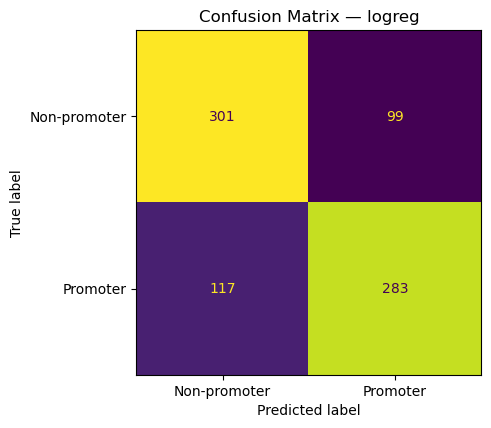

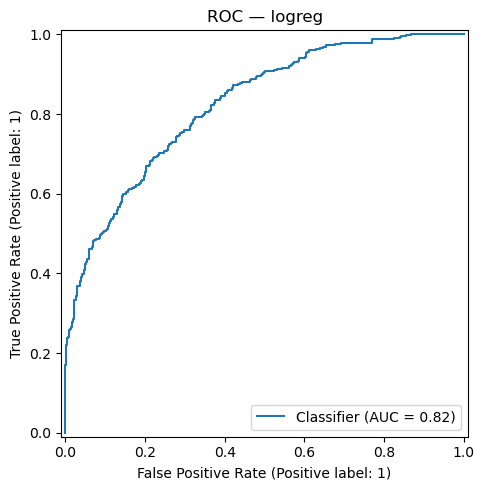

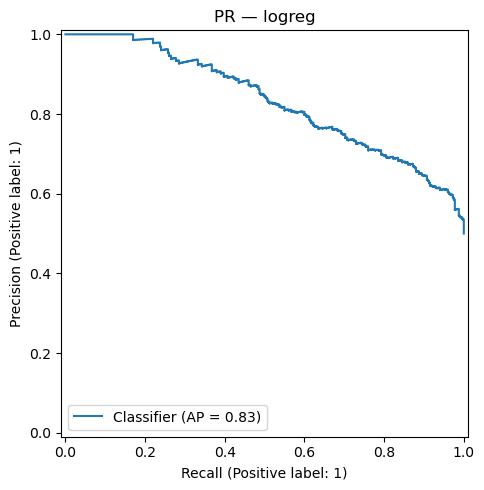

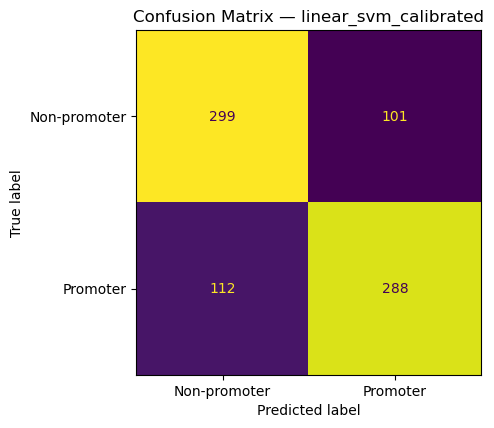

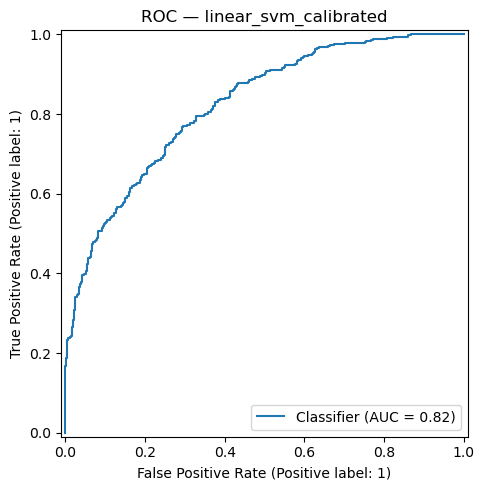

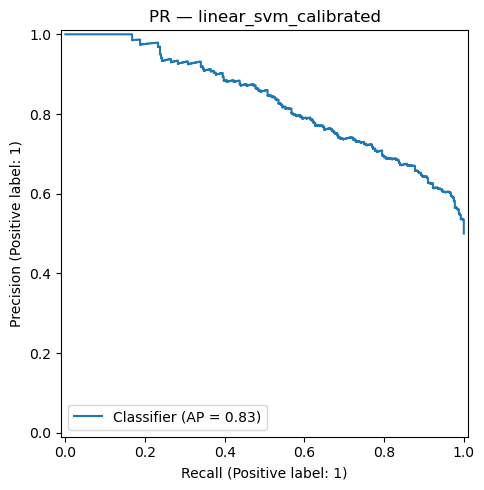

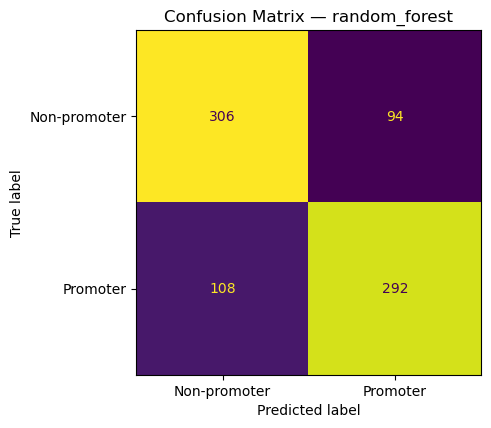

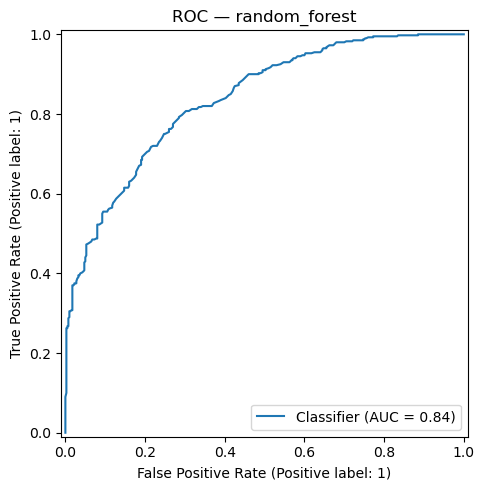

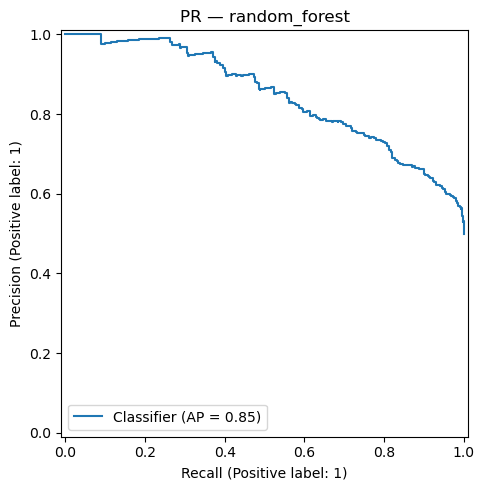

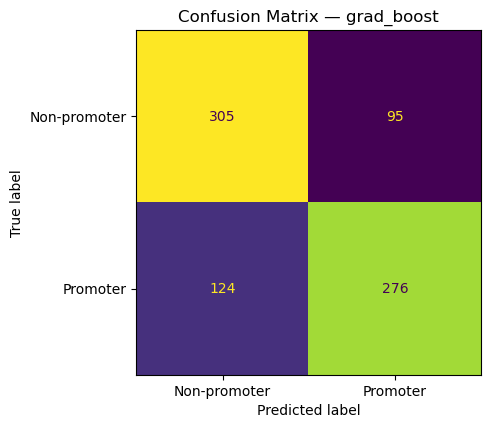

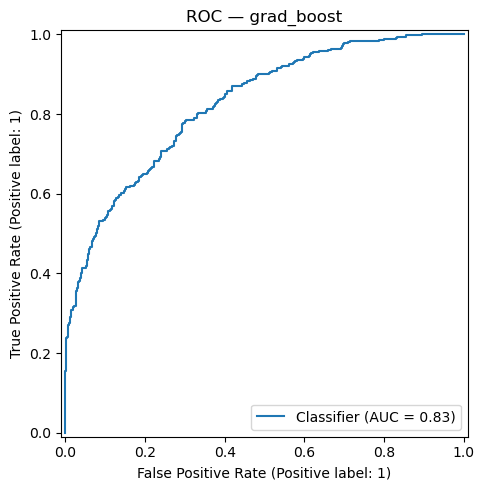

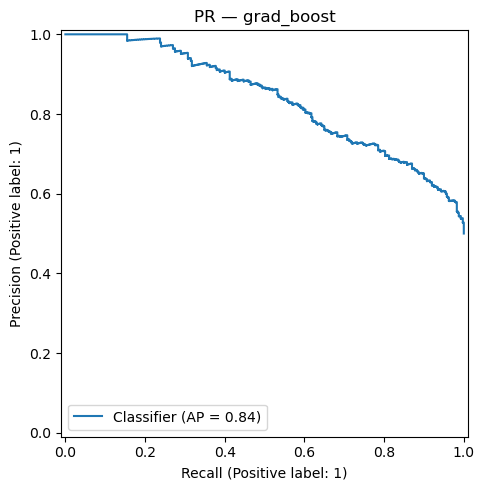

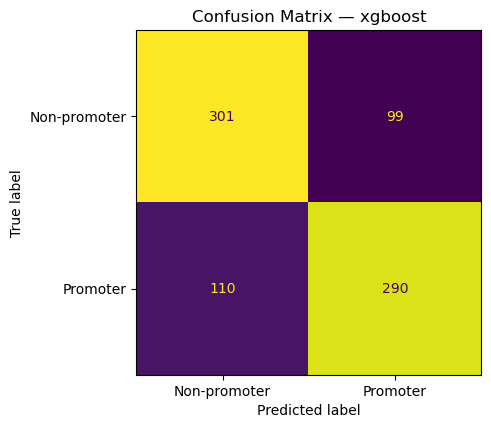

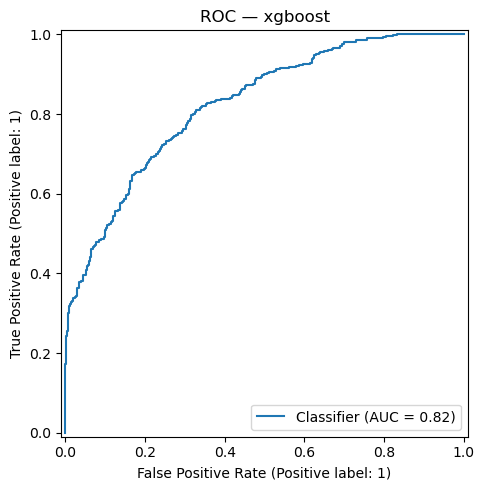

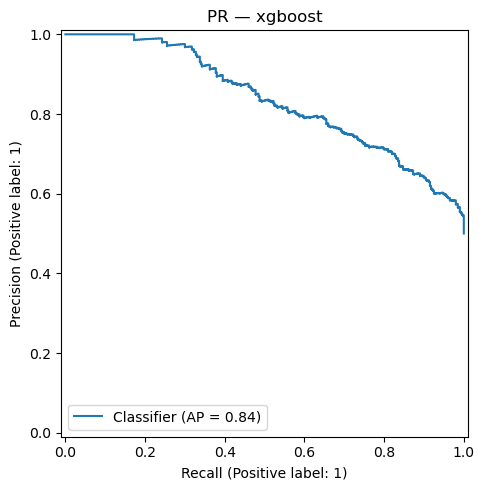

(15,
 [('cm_logreg',
   '/Users/saturnine/Projects/bio-seq-lm-capstone/reports/figures/dna_baselines/cm_logreg_len200.png'),
  ('roc_logreg',
   '/Users/saturnine/Projects/bio-seq-lm-capstone/reports/figures/dna_baselines/roc_logreg_len200.png'),
  ('pr_logreg',
   '/Users/saturnine/Projects/bio-seq-lm-capstone/reports/figures/dna_baselines/pr_logreg_len200.png')])

In [12]:
saved_figs = {}

for name, model in fitted_models.items():
    proba = get_proba(model, X_test)
    pred = (proba >= 0.5).astype(int)

    # Confusion matrix
    fig, ax = plt.subplots(figsize=(5, 5))
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-promoter", "Promoter"])
    disp.plot(ax=ax, values_format="d", colorbar=False)
    ax.set_title(f"Confusion Matrix — {name}")
    fig.tight_layout()
    cm_path = FIGURES / f"cm_{name}_len{L}.png"
    fig.savefig(cm_path, dpi=200)
    plt.show()
    plt.close(fig)
    saved_figs[f"cm_{name}"] = str(cm_path)

    # ROC curve
    fig, ax = plt.subplots(figsize=(6, 5))
    RocCurveDisplay.from_predictions(y_test, proba, ax=ax)
    ax.set_title(f"ROC — {name}")
    fig.tight_layout()
    roc_path = FIGURES / f"roc_{name}_len{L}.png"
    fig.savefig(roc_path, dpi=200)
    plt.show()
    plt.close(fig)
    saved_figs[f"roc_{name}"] = str(roc_path)

    # PR curve
    fig, ax = plt.subplots(figsize=(6, 5))
    PrecisionRecallDisplay.from_predictions(y_test, proba, ax=ax)
    ax.set_title(f"PR — {name}")
    fig.tight_layout()
    pr_path = FIGURES / f"pr_{name}_len{L}.png"
    fig.savefig(pr_path, dpi=200)
    plt.show()
    plt.close(fig)
    saved_figs[f"pr_{name}"] = str(pr_path)

len(saved_figs), list(saved_figs.items())[:3]

## 10) Save summary JSON

Includes:
- feature file used
- model list
- CV results path
- test results path
- where `.pkl` models were saved
- figure paths

In [13]:
summary = {
    "seed": int(SEED),
    "seq_length_bp": int(L),
    "n_pos": int(N_POS),
    "n_neg": int(N_NEG),
    "features_path": str(feat_path),
    "n_rows": int(df.shape[0]),
    "n_features": int(len(feature_cols)),
    "models_trained": list(fitted_models.keys()),
    "outputs": {
        "models_dir": str(MODELS_DIR),
        "cv_results_csv": str(cv_out),
        "test_results_csv": str(test_out),
        "figures_dir": str(FIGURES),
    },
    "figures": saved_figs,
    "topline_test": test_df.to_dict(orient="records"),
}

summary_path = REPORTS / f"dna_baseline_models_summary_len{L}.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

summary_path

PosixPath('/Users/saturnine/Projects/bio-seq-lm-capstone/reports/dna_baseline_models_summary_len200.json')